In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from pathlib import Path

BASE_DIR = Path.cwd().parent  # notebooks klasöründen bir üst dizine çık
DB_PATH = BASE_DIR / "data" / "raw" / "data.db"

conn = sqlite3.connect(DB_PATH)
print("Bağlantı başarılı:", DB_PATH)

Bağlantı başarılı: c:\Users\gokce_aktas\Desktop\dsml-assessment\data\raw\data.db


In [3]:
df_hedef = pd.read_sql('SELECT * FROM hedef', conn)
print(df_hedef.head())
print(df_hedef.dtypes)

  öğrenci_id hedef_degisken
0          1    286,6960835
1          2    339,4194585
2          3    271,1636283
3          4    307,9972813
4          5    328,1582231
öğrenci_id        object
hedef_degisken    object
dtype: object


In [4]:
df_hedef['hedef_degisken'] = df_hedef['hedef_degisken'].str.replace(',', '.')
df_hedef['hedef_degisken'] = pd.to_numeric(df_hedef['hedef_degisken'], errors='coerce')
print(df_hedef['hedef_degisken'].dtype)
print(df_hedef['hedef_degisken'].isnull().sum())
print(df_hedef['hedef_degisken'].describe())

float64
0
count    1004.000000
mean      300.096222
std        64.791991
min       164.928302
25%       253.866472
50%       294.000266
75%       345.870669
max       484.239987
Name: hedef_degisken, dtype: float64


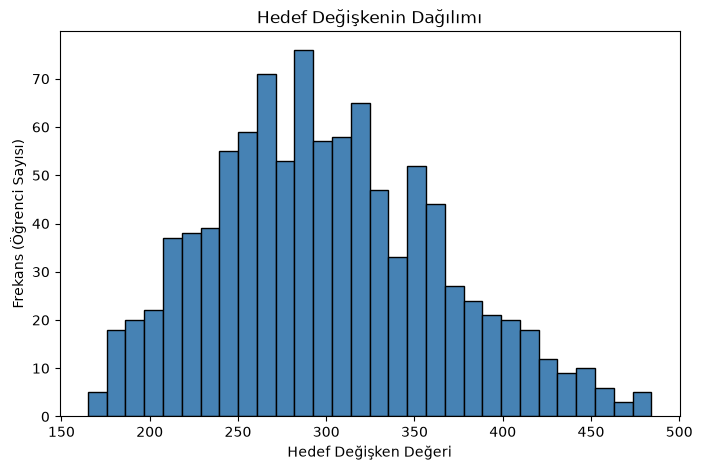

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df_hedef['hedef_degisken'], bins=30, color='steelblue', edgecolor='black')
plt.title("Hedef Değişkenin Dağılımı")
plt.xlabel("Hedef Değişken Değeri")
plt.ylabel("Frekans (Öğrenci Sayısı)")
plt.show()

Hedef değişken kolonları yani buradaki hedef değişkenimizin anlamı öğrencinin tahmin edilmesi istenen bir performans başarı skoru.

In [6]:
from scipy.stats import shapiro
stat, p = shapiro(df_hedef['hedef_degisken'].dropna())
print(stat, p)


0.9859780694128174 3.192194690100213e-08


Bu test, hedef_degisken sütununun normal dağılıma uyup uymadığını ölçüyor.

p-değeri Nedir?

P-değeri, istatistikte "gördüğüm bu sonucun, sadece tesadüfen ortaya çıkma olasılığı nedir?" sorusuna cevap veren bir sayı.

Shapiro Testi Nedir?

Normal dağılıma uyup uymadığını sayısal olarak test eder

Test, önce bir varsayım ile başlıyor:

"Bu veri, normal dağılımdan geliyor."

P-değeri şunu söylüyor:

"Eğer bu varsayım gerçekten doğruysa, elimdeki veri kadar 'normalden sapmış' bir örneklem görme ihtimalim nedir?"

Yorumlama Kuralı
p-değeri	Anlamı
p > 0.05	Sapma şansla açıklanabilir veri normal dağılıma uygun diyebiliriz
p ≤ 0.05	Sapma şansla açıklanamayacak kadar büyük  veri normal dağılıma uygun değil

p = 3.192194690100213e-08

Bu, 0.0000000319 demek yani 0.05'ten inanılmaz derecede küçük.

Sonuç: hedef_degisken sütunu, istatistiksel olarak normal dağılıma uymuyor.

stat (Test İstatistiği / W Değeri) Nedir?

Bu, Shapiro testinde W olarak da bilinir.

0 ile 1 arasında bir değerdir.

1'e ne kadar yakınsa, verinin şekli normale o kadar benziyor demektir.

stat = 0.9859780694128174 değeri 1'e çok yakın — yani veri görsel olarak normale oldukça benziyor.

Amacımız, hedef_degisken sütununun normal dağılıma uyup uymadığını sayısal/istatistiksel olarak kesin bir şekilde ölçmekti  yani sadece "gözle bakınca çan şekline benziyor" demek yerine, bunu test ederek kanıtlamak.


In [7]:
print(f"İstatistik: {stat}, p-değeri: {p}")

İstatistik: 0.9859780694128174, p-değeri: 3.192194690100213e-08


In [8]:
print(df_hedef['hedef_degisken'].skew())


0.35830563186446585


Skewness (Çarpıklık) Nedir?

Skewness, bir verinin dağılımının simetrik olup olmadığını ve hangi yöne doğru "kaydığını" ölçen bir sayıdır.

In [9]:
print(df_hedef.columns.tolist())

['öğrenci_id', 'hedef_degisken']


Bu tablomda (df_hedef) hangi sütunlar var, isimleri söyler

In [10]:
print(f"İstatistik: {stat}, p-değeri: {p}")

İstatistik: 0.9859780694128174, p-değeri: 3.192194690100213e-08


In [11]:
%who DataFrame

df_hedef	 


Şu ana kadar oluşturduğum tabloların (DataFrame'lerin) hepsini listeler.

In [12]:
"""
Bu kodu kendi notebook'una (01_explore_data.ipynb) hücre hücre yapıştır ve çalıştır.
data.db yolunu kendi projenine göre ayarla (aşağıda DB_PATH).
"""
 
import sqlite3
import struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [13]:
# ============================================
# 1. VERİYİ OKU VE BİRLEŞTİR
# ============================================
DB_PATH = '../data/raw/data.db'
  # kendi yoluna göre düzenle
 
conn = sqlite3.connect(DB_PATH)
hedef = pd.read_sql('SELECT * FROM hedef', conn)
notlar = pd.read_sql('SELECT * FROM "not"', conn)   # "not" SQL anahtar kelimesi, tırnak şart
ogrenci = pd.read_sql('SELECT * FROM ogrenci', conn)
 
df = ogrenci.merge(notlar, on='öğrenci_id').merge(hedef, on='öğrenci_id')
print("Shape:", df.shape)
df.head()
 

Shape: (1004, 25)


,öğrenci_id,okula_basladigi_yil,dogum_yil,okul_tip,kiminle_kaliyor,il,"cinsiyet(kiz=1, erkek=0)",burslu,anne_baba_ayri,aile_geliri_seviyesi,...,ontest_skoru,kayit_sira_no,donem,turkce_not_ort,matematik_not_ort,fen_not_ort,sosyal_not_ort,y_dil_not_ort,din_not_ort,hedef_degisken
0,1,2015-2016,2005,Tip 1,Ailesiyle,1,1,0.0,0,2.0,...,247.67,28289,2025-Güz,72,84,"84,33333333",69,"52,66666667","67,5","286,6960835"
1,2,2014-2015,2004,Tip 2,Ailesiyle,1,0,0.0,0,2.0,...,287.40,23434,2024-Güz,80,"73,33333333","85,66666667","86,5",84,None,"339,4194585"
2,3,2014-2015,2004,Tip 2,Ailesiyle,0,0,0.0,0,2.0,...,235.67,98696,2025-Bahar,41,42,57,53,"30,66666667","77,5","271,1636283"
3,4,2014-2015,2004,Tip 1,Ailesiyle,1,1,0.0,0,1.0,...,273.98,81482,2025-Güz,"78,66666667","82,66666667","85,33333333",87,84,"87,5","307,9972813"
4,5,2015-2016,2005,Tip 2,Ailesiyle,1,0,0.0,0,2.0,...,277.06,21395,2024-Güz,82,39,79,87,87,96,"328,1582231"


In [14]:
# ============================================
# 2. TEMİZLİK (byte hatası + Türkçe virgüllü sayılar)
# ============================================


def fix_bytes(v):
    # Bu fonksiyon TEK BİR değeri parametre olarak alır (v).
    # Amaç: SQLite'ın bazı satırlarda sayı yerine "ham byte" kaydetmiş
    # olmasını düzeltmek (örn: b'\xd5\x07\x00\x00\x00\x00\x00\x00' -> 200
    
    if isinstance(v, bytes):
         # isinstance(v, bytes) -> "v'nin TİPİ byte mi?" diye sorar, True/False döner.
        # Python'da veri tipini kontrol etmenin standart yolu budur.
 
        try:
    # try/except: "şunu dene, patlarsa (hata verirse) programı çökertme"
            
            return struct.unpack('<q', v)[0]
         # struct kütüphanesi: ham byte'ları anlamlı sayıya çevirir.
            # '<q' formatı = little-endian (byte sırası) + 8 byte'lık tam sayı (int64)
            # Bunu, örnek bir byte değerini elle deneyip 2005 gibi mantıklı
            # bir yıl çıktığını görerek bulduk.
            # unpack() bir TUPLE (demet) döndürür, örn: (2005,)
            # [0] ile o demetin içindeki tek sayıyı çekip alıyoruz.
 
        except:
            return np.nan
         # Eğer çözme işlemi başarısız olursa (format uymazsa),
            # hata vermek yerine NaN (boş/eksik değer) döndür.

    return v
# Eğer v zaten byte değilse (yani normal bir sayıysa), dokunmadan aynen geri ver.
 
 
def to_num_tr(v):
     # Bu fonksiyon Türkçe formatlı sayıları (virgüllü, örn "85,5") düzeltir.
    # Türkiye'de ondalık ayracı virgüldür, ama programlama dillerinde nokta beklenir.

    if isinstance(v, bytes):
        v = fix_bytes(v)
          # Önce byte ise, yukarıdaki fonksiyonla düzelt.

    if isinstance(v, str):
           # v bir metin (string) ise, örn "85,5" gibi

        v = v.replace(',', '.').strip()
          # .replace(',', '.') -> virgülü noktayla değiştir: "85,5" -> "85.5"
        # .strip() -> baştaki/sondaki boşlukları temizle (örn " 85.5 " -> "85.5")
        try:
            return float(v)
           # float() -> string'i ondalıklı sayıya çevirir: "85.5" -> 85.5

        except:
            return np.nan
         # Çevrilemezse (örn bozuk bir metinse) NaN döndür

    return v
 # v zaten sayıysa (string değilse), olduğu gibi geri ver.

 # ---- Fonksiyonları ilgili kolonlara uygulama ----
 
byte_cols = ['öğrenci_id', 'dogum_yil', 'il', 'cinsiyet(kiz=1, erkek=0)', 'anne_baba_ayri']
# Byte hatası olduğunu tespit ettiğimiz kolonların listesi.
# Bunu nasıl bulduk: df[col].unique() ile her kolonun benzersiz
# değerlerine bakıp b'\x...' gibi garip değerler gözümüze çarptı

for c in byte_cols:
    
    
    df[c] = df[c].apply(fix_bytes).astype('Int64')
    
 
 
num_str_cols = ['turkce_not_ort', 'matematik_not_ort', 'fen_not_ort', 'sosyal_not_ort',
                'y_dil_not_ort', 'din_not_ort', 'hedef_degisken']
for c in num_str_cols:
    df[c] = df[c].apply(to_num_tr)
    # Virgüllü/string olarak kaydedilmiş not kolonlarının listesi.
 
df['öğrenci_id'] = df['öğrenci_id'].astype(int)
# öğrenci_id kolonunu normal (nullable olmayan) tam sayı tipine çevir,
# çünkü bu kolonda eksik değer olmaması gerekir (her öğrencinin ID'si olmalı).
 
 # ---- Sonucu kontrol etme ----
 
print("Eksik değerler:")
print(df.isna().sum()[df.isna().sum() > 0])
# df.isna() -> her hücre için True/False döner (eksik mi değil mi?)
# .sum() -> her KOLONDA kaç tane True (eksik) var, sayar
# [df.isna().sum() > 0] -> sadece en az 1 eksiği olan kolonları filtrele,
#   sıfır eksiği olanları ekrana yazdırma (kalabalık yapmasın diye)
 
 

Eksik değerler:
burslu                   8
aile_geliri_seviyesi    68
kardes(var/yok)         20
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
ontest_skoru             5
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64


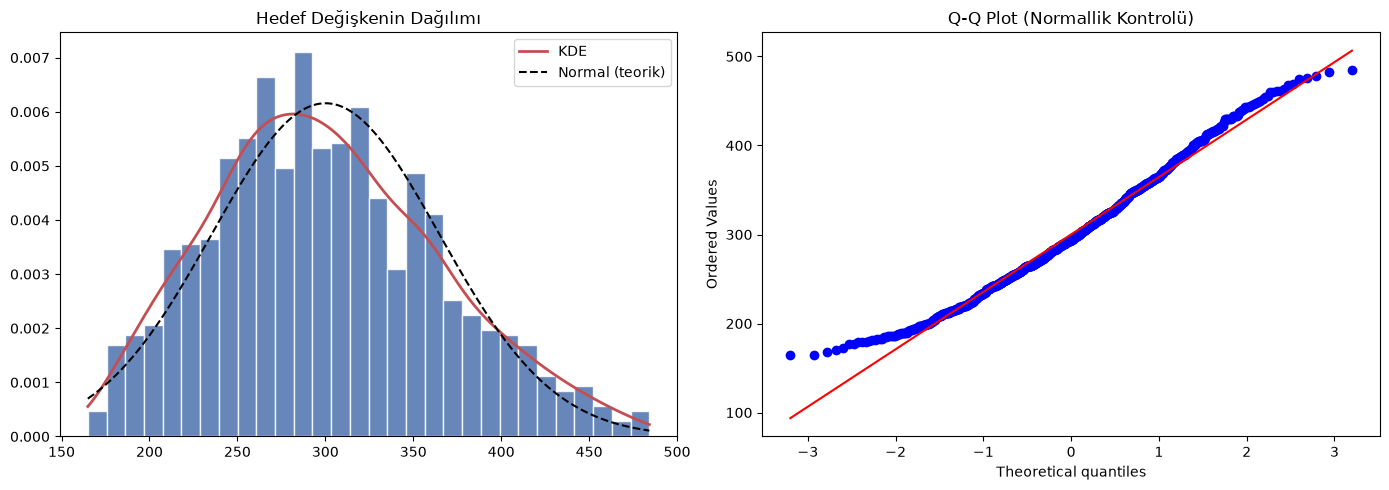

Çarpıklık: 0.3578 | Shapiro-Wilk p-value: 0.000000


In [15]:
# ============================================
# 3. GRAFİK 1: HEDEF DEĞİŞKENİN DAĞILIMI
# ============================================
hedef_col = df['hedef_degisken'].dropna()
 # df['hedef_degisken'] -> DataFrame'den sadece bu tek kolonu seç (bir Series olur)
# .dropna() -> içindeki eksik (NaN) değerleri at, sadece dolu olanları bırak.
# Neden: histogram/istatistik hesaplarken NaN varsa hata verir ya da
#   yanlış sonuç çıkar, o yüzden önce temizliyoruz.
# Sonucu hedef_col adlı yeni bir değişkende saklıyoruz, tekrar tekrar
#   df['hedef_degisken'].dropna() yazmamak için.
 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

 
# ---- SOL GRAFİK: Histogram + KDE + Normal eğri ----
 
 
axes[0].hist(hedef_col, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85, density=True)
xs = np.linspace(hedef_col.min(), hedef_col.max(), 200)
kde = stats.gaussian_kde(hedef_col)
axes[0].plot(xs, kde(xs), color='#C44E52', linewidth=2, label='KDE')
mu, sigma = hedef_col.mean(), hedef_col.std()

 
axes[0].plot(xs, stats.norm.pdf(xs, mu, sigma), color='black', linestyle='--', label='Normal (teorik)')
axes[0].set_title('Hedef Değişkenin Dağılımı')
axes[0].legend()

 
# ---- SAĞ GRAFİK: Q-Q Plot ----
 
stats.probplot(hedef_col, dist="norm", plot=axes[1])

 
axes[1].set_title('Q-Q Plot (Normallik Kontrolü)')

plt.tight_layout()
plt.show()

 
# ---- İstatistiksel testler: sayısal olarak normallik ölçümü ----
 
 
skew = stats.skew(hedef_col)

shapiro_stat, shapiro_p = stats.shapiro(hedef_col.sample(min(len(hedef_col), 5000), random_state=1))
print(f"Çarpıklık: {skew:.4f} | Shapiro-Wilk p-value: {shapiro_p:.6f}")

 

Mavi çubuklar histogramımız,kırmızı çizgi ise verimizin şeklini daha net görebilmek için var,siyah noktalar ise veri mükemmel normal dağılımı olsaydı böyle görünürdü anlamına geliyor.Normal dağılıma yakın gözüküyor ama Wilk testi yaptık ve istatiksel olarak olmadığını gördük.Sağa yatık bir grafik çünkü skewness (çarpıklık) 0.3578 pozitif bir değer.Ve şunu öğrendimki skewness değeri  pozitif 0.5'ten büyük ise sağa -0.5 ve 0.5 aralığında ise yaklaşık simetrik negatif -0.5'ten küçük ise sola yatık olur.

Q-Q Plot'ta ise veriler ne kadar kırmızı çizgiye yakınsa sapma o kadar az olur.Normal dağılıma uygun.

1.grafik'i veriler genel olarak tek tepeli mi, çan şeklinde mi, simetrik mi  kabaca bir ilk izlenim elde içindi.

2.grafik ise verinin her bir noktasının, tam normal dağılım olsaydı nerede olması gerektiğini ve en düşük ve en yüksek değerlerdeki sapmaları çok daha net yakalamak.

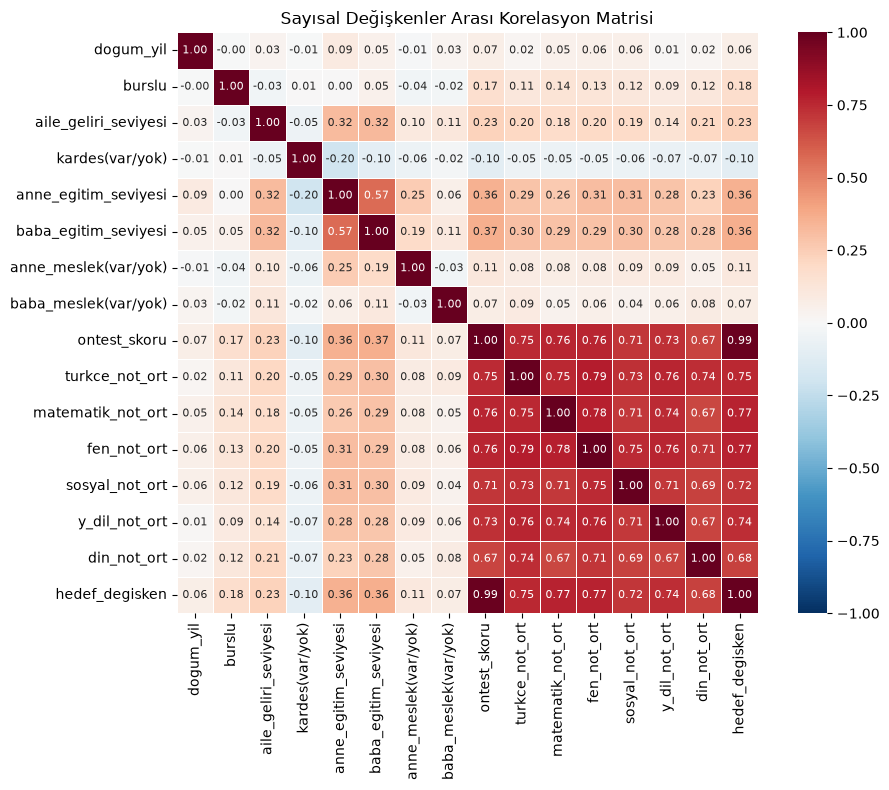

ontest_skoru            0.990002
fen_not_ort             0.769837
matematik_not_ort       0.768108
turkce_not_ort          0.754159
y_dil_not_ort           0.737431
sosyal_not_ort          0.718222
din_not_ort             0.681966
baba_egitim_seviyesi    0.363695
anne_egitim_seviyesi    0.355294
aile_geliri_seviyesi    0.226710
burslu                  0.175486
anne_meslek(var/yok)    0.108238
baba_meslek(var/yok)    0.072729
dogum_yil               0.063661
kardes(var/yok)        -0.102007
Name: hedef_degisken, dtype: float64


In [16]:
# ============================================
# 4. GRAFİK 2: KORELASYON MATRİSİ
# ============================================
num_cols = ['dogum_yil', 'burslu', 'aile_geliri_seviyesi', 'kardes(var/yok)',
            'anne_egitim_seviyesi', 'baba_egitim_seviyesi', 'anne_meslek(var/yok)',
            'baba_meslek(var/yok)', 'ontest_skoru', 'turkce_not_ort', 'matematik_not_ort',
            'fen_not_ort', 'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort', 'hedef_degisken']
 
corr = df[num_cols].corr(numeric_only=True)
 
plt.figure(figsize=(10 ,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')
plt.tight_layout()
plt.show()
 
print(corr['hedef_degisken'].drop('hedef_degisken').sort_values(ascending=False))
 

Korelasyon matrisi nedir ve okuyalım.
Veri setindeki tüm sayısal verilerin bir biri ile ne kadar bağlantılı olduğunu gösterir.
Her hücreye -1 ve +1 arasında değer veriyoruz ve 1 olduğunda  mükemmel pozitif ilişki, 0 olduğunda hiç ilişki yok ve -1 olduduğunda ise mükemmel negatif ilişki anlamına geliyor.
Koyu kırmızı +1
Beyaz 0'a yakın 
Koyu mavi -1
Neyi görmek istedim.Korelasyon matrisini çizmemizin temel amacı, hangi değişkenlerin birbiriyle ilişkili olduğunu, hangi değişkenlerin hedef değişkeni (hedef_degisken) etkileyebileceğini görmekti. 



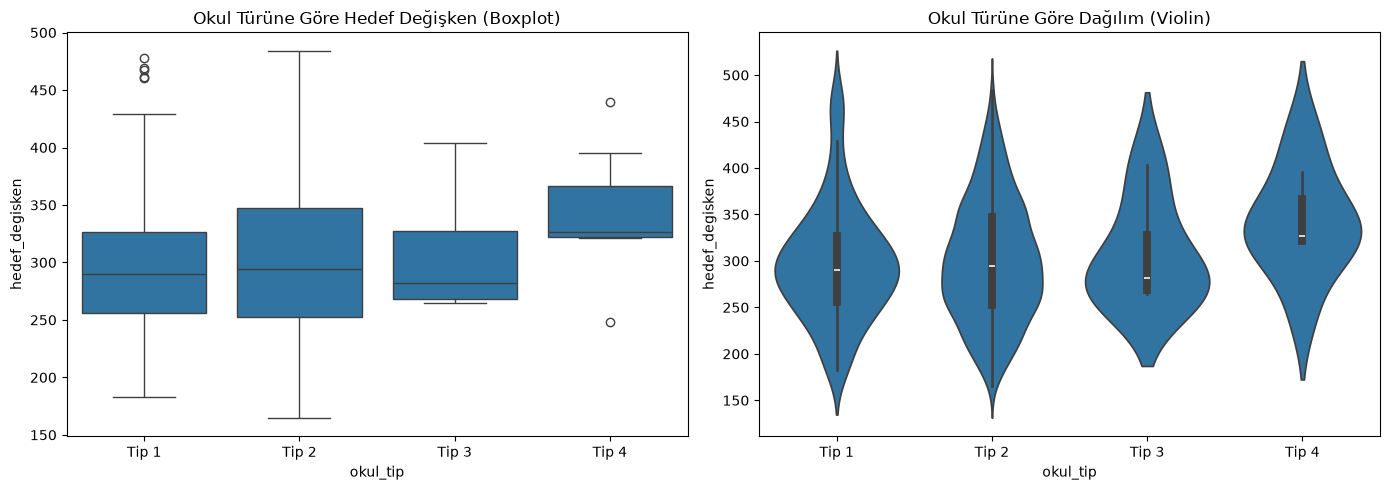

ANOVA: F=1.202, p=0.307999


In [17]:
# ============================================
# 5. GRAFİK 3: OKUL TÜRÜ vs HEDEF DEĞİŞKEN
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = sorted(df['okul_tip'].unique())
 
sns.boxplot(data=df, x='okul_tip', y='hedef_degisken', ax=axes[0], order=order)
axes[0].set_title('Okul Türüne Göre Hedef Değişken (Boxplot)')
 
sns.violinplot(data=df, x='okul_tip', y='hedef_degisken', ax=axes[1], order=order)
axes[1].set_title('Okul Türüne Göre Dağılım (Violin)')
plt.tight_layout()
plt.show()
 
groups = [g['hedef_degisken'].dropna().values for _, g in df.groupby('okul_tip')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={p_val:.6f}")

Okul Türüne Göre Hedef Değişken Boxplot grafiği,
Her kutu o gruba ait verinin özet istatisklerini veriyor.
Kutunun içindeki çizgi medyan ortanca değer.Kutunun boyu ne kadar yayıldığını gösterir ve kutu ne kadar büyükse o kadar çeşitlilik var anlamına geliyor.
Çizgilerimiz ise max ve min değerleri gösterirken  noktalar aykırı değerleri gösterir yani gruptan anormal şekilde uzaklar.Medyanlar sadece kutunun içindeki değerlere göre hesaplanır!

Violin grafiği,
Boxplotun gelişmiş versiyonuymuş, ek olarak dağılım şeklini gösterir.
Şeklin genişliği o değer aralığında ne kadar öğrenci olduğunu gösterir.
Ne kadar genişse o kadar veri olduğu anlamına geliyor.İçindeki beyaz çizgiler medyanı gösteriyor.Şeklin yüksekliği verinin en düşük ve en yüksek değerlerini gösteriyor.

Neler görmek için neden yaptım.
Bu iki grafiği çizmemizin temel amacı, okul_tip değişkeninin hedef_degisken üzerinde bir etkisi var mı, yok mu sorusuna cevap aramaktı.

ANOVA Testi Ne Yapar?

ANOVA 3 veya daha fazla grubun ortalamalarını karşılaştırmak için kullanılır.

Boxplot ve Violin plot'ta gözle gördüğümüz grup farklarının, istatistiksel olarak gerçek/anlamlı olup olmadığını test eden sonuç.


F Değeri Nedir?

F = 1.202

F değeri, gruplar arasındaki farkın, grupların kendi içindeki farka  oranını gösterir.
F ne kadar büyükse, gruplar arasındaki fark o kadar belirgin demektir.
F = 1'e yakın değerler, gruplar arası farkın grup içi farktan pek de büyük olmadığını gösterir.

 F = 1.202 değeri, 1'e oldukça yakın yani gruplar arası fark ile grup içi doğal değişkenlik birbirine benzer büyüklükte. Bu, güçlü bir grup farkı olmadığına işaret ediyor.

P-değeri Nedir? 

p = 0.307999

p-değeri	Anlamı
p > 0.05	Fark, şansla açıklanabilir  
p ≤ 0.05	Fark, şansla açıklanamayacak kadar büyük  

Sizin p = 0.308, 0.05'ten çok büyük.

Sonuç

Okul türleri arasında, hedef_degisken açısından istatistiksel olarak anlamlı bir fark yok.


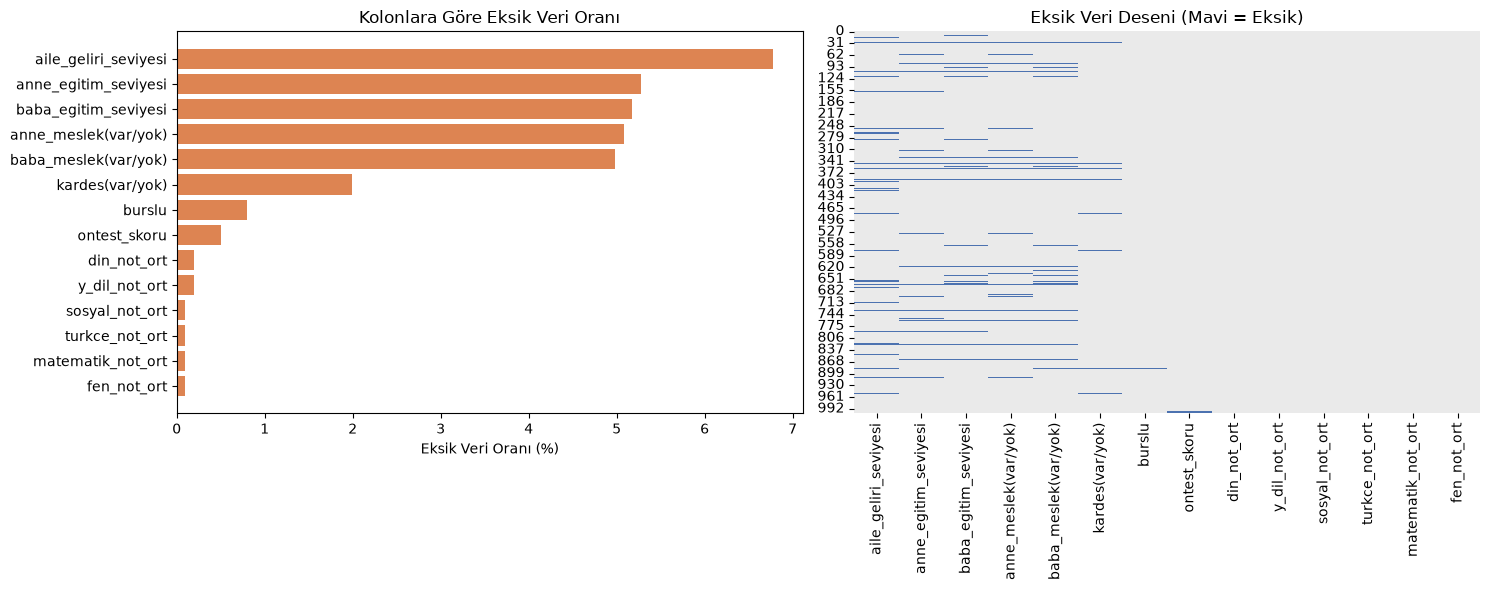

                 anne_egt_eksik  baba_egt_eksik
kiminle_kaliyor                                
Ailesiyle              0.044330        0.043299
Annesiyle              0.280000        0.360000
Babasıyla              0.166667        0.000000
Velisiyle              0.666667        0.333333


In [18]:
# ============================================
# 6. GRAFİK 4: EKSİK VERİ DESENİ
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
axes[0].barh(miss.index, miss.values * 100, color='#DD8452')
axes[0].set_xlabel('Eksik Veri Oranı (%)')
axes[0].set_title('Kolonlara Göre Eksik Veri Oranı')
axes[0].invert_yaxis()
 
miss_cols = miss.index.tolist()
sns.heatmap(df[miss_cols].isna(), cbar=False, cmap=['#EAEAEA', '#4C72B0'], ax=axes[1])
axes[1].set_title('Eksik Veri Deseni (Mavi = Eksik)')
plt.tight_layout()
plt.show()
 
# MAR testi: eksiklik gözlenen bir değişkenle ilişkili mi?
df['anne_egt_eksik'] = df['anne_egitim_seviyesi'].isna().astype(int)
df['baba_egt_eksik'] = df['baba_egitim_seviyesi'].isna().astype(int)
print(df.groupby('kiminle_kaliyor')[['anne_egt_eksik', 'baba_egt_eksik']].mean())

#1.grafik kolonlara göre eksik veri oranı

#2.grafik matrix desen grafiği

Eksiklikler özellikle aile_geliri_seviyesi, anne_egitim_seviyesi, baba_egitim_seviyesi, anne_meslek, baba_meslek sütunlarında belirli satır aralıklarında kümelenmiş görünüyor.

Bu, eksikliğin rastgele dağılmadığını, belirli öğrenci gruplarında (belki belirli okullarda, belirli veri toplama dönemlerinde) birlikte ortaya çıktığını gösteriyor olabilir.

din_not_ort sütununda sadece bir tek mavi çizgi var (992 civarı) — yani neredeyse tamamen dolu.

ontest_skoru sütununda birkaç dağınık mavi çizgi var

In [19]:
import os
print(os.path.exists('../data/raw/data.db'))
print(os.path.exists('../data/raw/data.db'))

True
True


BÖLÜM 3

## Data Leakage

**Korelasyonu hesapla**

In [20]:
korelasyon_degeri = df['ontest_skoru'].corr(df['hedef_degisken'])
print(f"ontest_skoru ile hedef_degisken arasındaki korelasyon: {korelasyon_degeri:.3f}")

ontest_skoru ile hedef_degisken arasındaki korelasyon: 0.990


**Ne yaptım?** `ontest_skor` ile `hedef_degisken` arasındaki korelasyon katsayısını hesapladım.

**Neden yaptım?** Feature engineering ve modelleme öncesinde, hangi sütunların hedef değişkenle "şüpheli" derecede güçlü bir ilişkisi olduğunu sayısal olarak tespit etmem gerekiyordu.

**Amacım neydi?** Bu iki değişken arasındaki ilişkinin gücünü tek bir sayıyla ölçüp, bir sonraki adımda görselleştirmeyle karşılaştırabileceğim bir referans değer elde etmekti.

**Ne gördüm?** Korelasyon değeri 0.99 çıktı — bu, normal bir öznitelikte beklenmeyecek kadar yüksek bir değer.

**Sonuç:** Bu kadar yüksek bir korelasyon, veri sızıntısı şüphesini güçlendiriyor; bir sonraki adımda bunu saçılım grafiğiyle görsel olarak da doğrulayacağım.

**Çıkarma (drop) hücresi için**

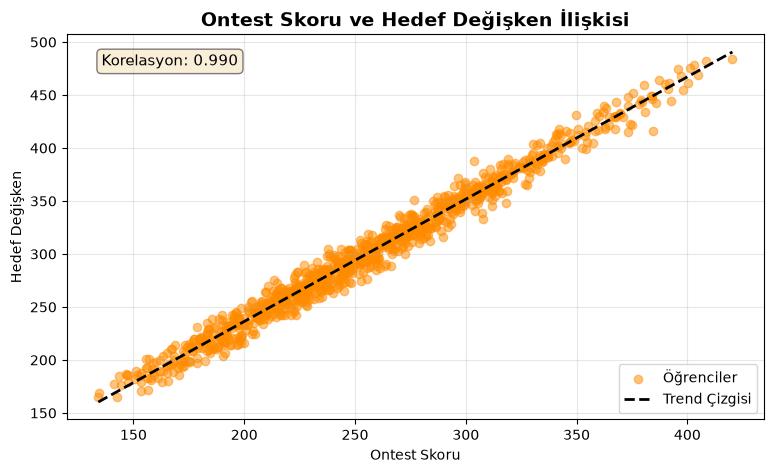

In [21]:
# Trend çizgisi hesaplaması için NaN olmayan satırları ayrı bir alt küme olarak alıyoruz
gecici = df[['ontest_skoru', 'hedef_degisken']].dropna()

plt.figure(figsize=(9, 5))
plt.scatter(df['ontest_skoru'], df['hedef_degisken'], alpha=0.5, color='darkorange', label='Öğrenciler')

z = np.polyfit(gecici['ontest_skoru'], gecici['hedef_degisken'], 1)
p = np.poly1d(z)
x_cizgi = np.linspace(gecici['ontest_skoru'].min(), gecici['ontest_skoru'].max(), 100)
plt.plot(x_cizgi, p(x_cizgi), color='black', linewidth=2, linestyle='--', label='Trend Çizgisi')

plt.title('Ontest Skoru ve Hedef Değişken İlişkisi', fontsize=14, fontweight='bold')
plt.xlabel('Ontest Skoru')
plt.ylabel('Hedef Değişken')
plt.text(0.05, 0.95, f'Korelasyon: {korelasyon_degeri:.3f}',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Ne yaptım?** ``ontest_skoru`` ile ``hedef_degisken`` arasındaki ilişkiyi saçılım grafiğiyle görselleştirdim.

**Neden yaptım?** Korelasyon analizinde bu iki değişken arasında 0.99 gibi çok yüksek bir korelasyon bulmuştum, bunu gözle de doğrulamak istedim.

**Amacım neydi?** Bu ilişkinin gerçekten bu kadar güçlü olup olmadığını, noktaların düz bir çizgiye ne kadar yakın durduğunu görmekti.

**Ne gördüm?** Noktalar neredeyse tamamen trend çizgisinin üzerinde. Bu, iki değişkenin neredeyse aynı bilgiyi taşıdığını gösteriyor.

**Sonuç:** ``ontest_skoru``, hedef değişkeni öğrenmek yerine kopyalamaya (data leakage) neden olacağı için model eğitiminde kullanılmayacak.

**Ontest Skorunun Veri Setinden Çıkarılması**

In [22]:
leakage_kolonlari = ['ontest_skoru']
df = df.drop(columns=leakage_kolonlari, errors='ignore')

**Ne yaptım?** ``ontest_skoru`` sütununu ``df``'den kalıcı olarak çıkardım.

**Neden yaptım?** Yukarıdaki korelasyon değeri ve saçılım grafiği, bu sütunun hedef değişkenle neredeyse birebir örtüştüğünü, yani veri sızıntısına neden olacağını gösterdi.

**Amacım neydi?** Modelin, gerçek tahmin anında elinde olmayacak bir bilgiden "kopya çekmesini" engellemek, böylece model performansının gerçekçi ve güvenilir olmasını sağlamaktı.

**Ne gördüm?** Sütun başarıyla çıkarıldı, ``df``'in sütun sayısı bir azaldı.

**Sonuç:** ``ontest_skoru`` artık öznitelik listesinde yer almıyor; bundan sonraki tüm adımlar (imputation, feature engineering, encoding, modelleme) bu sütun olmadan ilerleyecek.

**Doğrulama hücresi için**

In [23]:
print("Kaldırılan sızıntı sütunları:", leakage_kolonlari)
print("Güncel df shape:", df.shape)
print("Kalan sütunlar:")
for i, kolon in enumerate(df.columns, 1):
    print(f"{i}. {kolon}")

Kaldırılan sızıntı sütunları: ['ontest_skoru']
Güncel df shape: (1004, 26)
Kalan sütunlar:
1. öğrenci_id
2. okula_basladigi_yil
3. dogum_yil
4. okul_tip
5. kiminle_kaliyor
6. il
7. cinsiyet(kiz=1, erkek=0)
8. burslu
9. anne_baba_ayri
10. aile_geliri_seviyesi
11. kardes(var/yok)
12. anne_egitim_seviyesi
13. baba_egitim_seviyesi
14. anne_meslek(var/yok)
15. baba_meslek(var/yok)
16. kayit_sira_no
17. donem
18. turkce_not_ort
19. matematik_not_ort
20. fen_not_ort
21. sosyal_not_ort
22. y_dil_not_ort
23. din_not_ort
24. hedef_degisken
25. anne_egt_eksik
26. baba_egt_eksik


**Sonucun Doğrulanması**

**Ne yaptım?** Çıkarma işleminden sonra ``df``'in güncel boyutunu ve kalan sütunların tam listesini yazdırdım.

**Neden yaptım?** Drop işleminin gerçekten başarılı olduğundan ve yanlışlıkla başka bir sütunu silmediğimden emin olmak istedim.

**Amacım neydi?** Görsel bir kontrol ile, ``ontest_skoru``'nun listede olmadığını ve diğer tüm sütunların yerinde durduğunu teyit etmekti.

**Ne gördüm?** Kalan sütunlar listesinde ``ontest_skoru`` yok, shape bir sütun azalmış durumda — beklenen sonuç doğrulandı.

**Sonuç:** Veri sızıntısı temizliği başarıyla tamamlandı, artık imputation (eksik veri doldurma) adımına güvenle geçebiliriz.

## Eksik Veri Tamamlama

In [24]:
# İkili (binary, var/yok) sütunlar - 0/1 değer alacaklar
binary_cols = ['burslu', 'kardes(var/yok)', 'anne_meslek(var/yok)', 'baba_meslek(var/yok)']

# Sıralı/sayısal (ordinal-numeric) sütunlar - sürekli değer alabilecekler
numeric_cols = ['aile_geliri_seviyesi', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi',
                 'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',
                 'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort']

# Doldurma öncesi kontrol
print("Doldurma ÖNCESİ eksik sayıları:")
print(df[binary_cols + numeric_cols].isna().sum())

Doldurma ÖNCESİ eksik sayıları:
burslu                   8
kardes(var/yok)         20
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
aile_geliri_seviyesi    68
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64


In [25]:
# Orijinal (eksikli) veriyi, karşılaştırma yapabilmek için ayrı bir isimde saklıyoruz
df_orijinal = df.copy()

print("Orijinal veri kopyalandı. Eksik sayıları:")
print(df_orijinal[binary_cols + numeric_cols].isna().sum())

Orijinal veri kopyalandı. Eksik sayıları:
burslu                   8
kardes(var/yok)         20
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
aile_geliri_seviyesi    68
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64


In [26]:
df_medyan = df_orijinal.copy()

for c in numeric_cols:  # örn: aile_geliri_seviyesi, anne_egitim_seviyesi ...
    medyan_deger = df_medyan[c].median()
    df_medyan[c] = df_medyan[c].fillna(medyan_deger)
    print(f"{c} -> medyan değeri: {medyan_deger}")

aile_geliri_seviyesi -> medyan değeri: 2.0
anne_egitim_seviyesi -> medyan değeri: 1.0
baba_egitim_seviyesi -> medyan değeri: 1.0
turkce_not_ort -> medyan değeri: 73.33333333
matematik_not_ort -> medyan değeri: 64.33333333
fen_not_ort -> medyan değeri: 71.0
sosyal_not_ort -> medyan değeri: 75.0
y_dil_not_ort -> medyan değeri: 68.83333333499999
din_not_ort -> medyan değeri: 85.0


In [27]:
from sklearn.linear_model import LinearRegression

df_regresyon = df_orijinal.copy()

for hedef_col in numeric_cols:
    # Bu sütunda eksik olan satırlar
    eksik_mask = df_regresyon[hedef_col].isna()

    if eksik_mask.sum() == 0:
        continue  # eksik yoksa atla

    # Tahmin için kullanılacak diğer sayısal sütunlar (eksiği olmayan satırlarla eğitilecek)
    predictor_cols = [c for c in numeric_cols if c != hedef_col]

    # Eğitim seti: hedef_col'da eksik OLMAYAN satırlar, predictor sütunlarında da eksik olmayanlar
    egitim_veri = df_regresyon.dropna(subset=[hedef_col] + predictor_cols)
    X_egitim = egitim_veri[predictor_cols]
    y_egitim = egitim_veri[hedef_col]

    # Tahmin edilecek satırlar: hedef_col'da eksik olan, predictor'larda eksik olmayan
    tahmin_veri = df_regresyon.loc[eksik_mask].dropna(subset=predictor_cols)

    if len(tahmin_veri) == 0 or len(egitim_veri) == 0:
        # Yeterli veri yoksa medyan ile doldur (fallback)
        df_regresyon[hedef_col] = df_regresyon[hedef_col].fillna(df_regresyon[hedef_col].median())
        print(f"{hedef_col} -> yeterli veri yok, medyan ile dolduruldu")
        continue

    model = LinearRegression()
    model.fit(X_egitim, y_egitim)

    tahmin_degerler = model.predict(tahmin_veri[predictor_cols])
    df_regresyon.loc[tahmin_veri.index, hedef_col] = tahmin_degerler

    print(f"{hedef_col} -> {len(tahmin_veri)} satır regresyon ile dolduruldu")

# Regresyonla doldurulamayan (predictor'larda da eksik olan) kalan satırlar için medyan fallback
for c in numeric_cols:
    kalan_eksik = df_regresyon[c].isna().sum()
    if kalan_eksik > 0:
        df_regresyon[c] = df_regresyon[c].fillna(df_regresyon[c].median())
        print(f"{c} -> kalan {kalan_eksik} satır medyan ile dolduruldu (fallback)")

aile_geliri_seviyesi -> 34 satır regresyon ile dolduruldu
anne_egitim_seviyesi -> 11 satır regresyon ile dolduruldu
baba_egitim_seviyesi -> 9 satır regresyon ile dolduruldu
turkce_not_ort -> yeterli veri yok, medyan ile dolduruldu
matematik_not_ort -> yeterli veri yok, medyan ile dolduruldu
fen_not_ort -> yeterli veri yok, medyan ile dolduruldu
sosyal_not_ort -> yeterli veri yok, medyan ile dolduruldu
y_dil_not_ort -> 1 satır regresyon ile dolduruldu
din_not_ort -> 1 satır regresyon ile dolduruldu
aile_geliri_seviyesi -> kalan 34 satır medyan ile dolduruldu (fallback)
anne_egitim_seviyesi -> kalan 42 satır medyan ile dolduruldu (fallback)
baba_egitim_seviyesi -> kalan 43 satır medyan ile dolduruldu (fallback)
y_dil_not_ort -> kalan 1 satır medyan ile dolduruldu (fallback)
din_not_ort -> kalan 1 satır medyan ile dolduruldu (fallback)


In [28]:
df_mod = df_orijinal.copy()

for c in binary_cols:  # örn: burslu, kardes(var/yok), anne_meslek(var/yok)...
    mod_deger = df_mod[c].mode()[0]
    df_mod[c] = df_mod[c].fillna(mod_deger)
    print(f"{c} -> mod değeri: {mod_deger}")

burslu -> mod değeri: 0.0
kardes(var/yok) -> mod değeri: 0.0
anne_meslek(var/yok) -> mod değeri: 0.0
baba_meslek(var/yok) -> mod değeri: 1.0


In [29]:
df_ortalama = df_orijinal.copy()

for c in numeric_cols:  # örn: aile_geliri_seviyesi, anne_egitim_seviyesi ...
    ortalama_deger = df_ortalama[c].mean()
    df_ortalama[c] = df_ortalama[c].fillna(ortalama_deger)
    print(f"{c} -> ortalama değeri: {ortalama_deger:.3f}")

aile_geliri_seviyesi -> ortalama değeri: 2.049
anne_egitim_seviyesi -> ortalama değeri: 1.226
baba_egitim_seviyesi -> ortalama değeri: 1.492
turkce_not_ort -> ortalama değeri: 70.730
matematik_not_ort -> ortalama değeri: 62.631
fen_not_ort -> ortalama değeri: 69.083
sosyal_not_ort -> ortalama değeri: 71.774
y_dil_not_ort -> ortalama değeri: 66.779
din_not_ort -> ortalama değeri: 81.231


In [30]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

df_knn = df_orijinal.copy()

# KNN, ölçek farklarına duyarlıdır (örneğin not sütunları 0-100 arası, eğitim seviyesi 0-3 arası)
# Bu yüzden veriyi standartlaştırıp (ölçeklendirip) sonra KNN uyguluyoruz, sonra geri dönüştürüyoruz

cols_to_impute = binary_cols + numeric_cols

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_knn[cols_to_impute])

knn_imputer = KNNImputer(n_neighbors=5)
imputed_scaled = knn_imputer.fit_transform(scaled_data)

# Ölçeklendirmeyi geri alıyoruz (orijinal birimlere dönüyoruz)
imputed_original_scale = scaler.inverse_transform(imputed_scaled)

df_knn[cols_to_impute] = imputed_original_scale

print("KNN ile doldurma tamamlandı.")
print(df_knn[cols_to_impute].isna().sum())

KNN ile doldurma tamamlandı.
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [31]:
df_grup = df_orijinal.copy()

for c in numeric_cols:
    df_grup[c] = df_grup.groupby('kiminle_kaliyor')[c].transform(lambda x: x.fillna(x.median()))

for c in binary_cols:
    df_grup[c] = df_grup.groupby('kiminle_kaliyor')[c].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median())
    )

for c in numeric_cols + binary_cols:
    kalan = df_grup[c].isna().sum()
    if kalan > 0:
        df_grup[c] = df_grup[c].fillna(df_orijinal[c].median())
        print(f"{c} -> kalan {kalan} satır genel medyan ile dolduruldu (fallback)")

print("Grup bazlı doldurma tamamlandı.")
print(df_grup[binary_cols + numeric_cols].isna().sum())

Grup bazlı doldurma tamamlandı.
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [32]:
print("1. Doldurma öncesi eksik veri sayıları:")
print(df_orijinal[binary_cols + numeric_cols].isna().sum())
print()

kiminle_dummies = pd.get_dummies(df_orijinal['kiminle_kaliyor'], prefix='kiminle')

impute_cols = binary_cols + numeric_cols
impute_input = pd.concat([df_orijinal[impute_cols], kiminle_dummies], axis=1)

print("impute_input shape:", impute_input.shape)

1. Doldurma öncesi eksik veri sayıları:
burslu                   8
kardes(var/yok)         20
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
aile_geliri_seviyesi    68
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64

impute_input shape: (1004, 17)


In [33]:
import warnings
warnings.filterwarnings('ignore')  # ConvergenceWarning gibi zararsız uyarıları gizler

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=25,
    random_state=42,
    verbose=2  # her iterasyonun ilerlemesini ekrana yazdırır
)

print("Model tanımlandı, doldurma başlıyor (max_iter=25)...")
print("Bu işlem birkaç dakika sürebilir, lütfen bekleyin.")

impute_output = imputer.fit_transform(impute_input)

print("Doldurma tamamlandı.")

Model tanımlandı, doldurma başlıyor (max_iter=25)...
Bu işlem birkaç dakika sürebilir, lütfen bekleyin.
[IterativeImputer] Completing matrix with shape (1004, 17)
[IterativeImputer] Ending imputation round 1/25, elapsed time 3.92
[IterativeImputer] Change: 18.955384199504287, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 2/25, elapsed time 6.92
[IterativeImputer] Change: 21.77333333180004, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 3/25, elapsed time 10.90
[IterativeImputer] Change: 25.93333333219998, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 4/25, elapsed time 14.01
[IterativeImputer] Change: 17.196666664999967, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 5/25, elapsed time 16.83
[IterativeImputer] Change: 11.473333332199992, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 6/25, elapsed time 19.71
[IterativeImputer] Change: 10.753333333200054, scaled tolerance: 0.15 
[Iterat

In [34]:
impute_output_df = pd.DataFrame(impute_output, columns=impute_input.columns, index=df_orijinal.index)

# Binary ve ordinal sütunları tam sayıya yuvarlıyoruz
binary_cols_yuvarla = binary_cols + ['aile_geliri_seviyesi', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi']
for kolon in binary_cols_yuvarla:
    impute_output_df[kolon] = impute_output_df[kolon].round()

# Sonucu gerçek df'e yazıyoruz (karşılaştırma tablosu buradan okuyacak)
df[impute_cols] = impute_output_df[impute_cols]

print("MICE ile doldurma sonrası eksik veri sayıları:")
print(df[impute_cols].isna().sum())

MICE ile doldurma sonrası eksik veri sayıları:
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [35]:
df_mice_rf = df.copy()

print("df_mice_rf oluşturuldu (RandomForest ile MICE sonucu).")

df_mice_rf oluşturuldu (RandomForest ile MICE sonucu).


In [36]:
from sklearn.ensemble import ExtraTreesRegressor

imputer_et = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=50, random_state=42),
    max_iter=25,
    random_state=42,
    verbose=2
)

print("ExtraTrees ile MICE başlıyor...")
impute_output_et = imputer_et.fit_transform(impute_input)
print("Doldurma tamamlandı.")

impute_output_et_df = pd.DataFrame(impute_output_et, columns=impute_input.columns, index=df_orijinal.index)

for kolon in binary_cols_yuvarla:
    impute_output_et_df[kolon] = impute_output_et_df[kolon].round()

df_mice_et = df_orijinal.copy()
df_mice_et[impute_cols] = impute_output_et_df[impute_cols]

print("ExtraTrees MICE sonrası eksik veri sayıları:")
print(df_mice_et[impute_cols].isna().sum())

ExtraTrees ile MICE başlıyor...
[IterativeImputer] Completing matrix with shape (1004, 17)
[IterativeImputer] Ending imputation round 1/25, elapsed time 2.19
[IterativeImputer] Change: 20.07602893374716, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 2/25, elapsed time 4.24
[IterativeImputer] Change: 14.379999999999974, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 3/25, elapsed time 6.35
[IterativeImputer] Change: 7.983333332200097, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 4/25, elapsed time 8.47
[IterativeImputer] Change: 17.149999999400045, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 5/25, elapsed time 10.58
[IterativeImputer] Change: 17.176666666200042, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 6/25, elapsed time 12.67
[IterativeImputer] Change: 7.933333331600082, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 7/25, elapsed time 14.92
[IterativeImpu

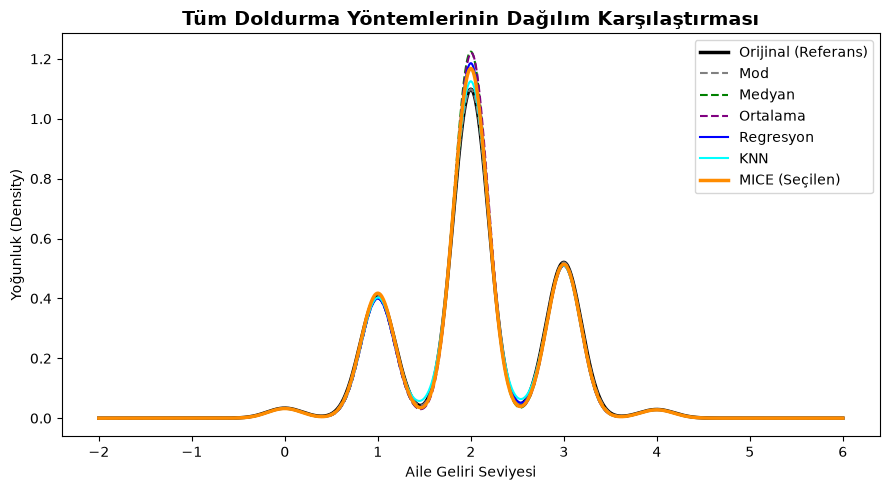

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

yontemler = {
    'Orijinal (Referans)': (df_orijinal['aile_geliri_seviyesi'].dropna(), 'black', 2.5, '-'),
    'Mod': (df_mod['aile_geliri_seviyesi'], 'gray', 1.5, '--'),
    'Medyan': (df_medyan['aile_geliri_seviyesi'], 'green', 1.5, '--'),
    'Ortalama': (df_ortalama['aile_geliri_seviyesi'], 'purple', 1.5, '--'),
    'Regresyon': (df_regresyon['aile_geliri_seviyesi'], 'blue', 1.5, '-'),
    'KNN': (df_knn['aile_geliri_seviyesi'], 'cyan', 1.5, '-'),
    'MICE (Seçilen)': (df['aile_geliri_seviyesi'], 'darkorange', 2.5, '-')
}

for isim, (veri, renk, kalinlik, stil) in yontemler.items():
    veri.plot(kind='kde', ax=ax, color=renk, linewidth=kalinlik, linestyle=stil, label=isim)

ax.set_title('Tüm Doldurma Yöntemlerinin Dağılım Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xlabel('Aile Geliri Seviyesi')
ax.set_ylabel('Yoğunluk (Density)')
ax.legend()
plt.tight_layout()
plt.show()

## Görsel Karşılaştırma: Yöntemlere Göre Dağılım Histogramları

**Ne yaptım?** Tüm doldurma yöntemlerinin `aile_geliri_seviyesi` dağılımını, 
orijinal (eksiksiz kısım) dağılımla birlikte KDE grafiğinde karşılaştırdım.

**Ne gördüm?** Mod ve Ortalama yöntemleri, 2 değerindeki tepe noktasını orijinale 
göre yapay olarak yükseltiyor — bu, sabit bir değerle doldurmanın dağılımı 
bozduğunu gösteriyor. MICE (turuncu), orijinal dağılıma en yakın seyreden 
yöntem; her satır için ayrı, veriye dayalı bir tahmin ürettiği için dağılımın 
doğal şeklini koruyor.

**Sonuç:** Bu görsel karşılaştırma, MICE'ın diğer yöntemlere göre dağılımı 
daha az bozduğunu destekliyor.

In [38]:
karsilastirma = pd.DataFrame({
    'Orijinal (eksiksiz kısım)': df_orijinal['aile_geliri_seviyesi'].dropna(),
    'Mod': df_mod['aile_geliri_seviyesi'],
    'Medyan': df_medyan['aile_geliri_seviyesi'],
    'Ortalama': df_ortalama['aile_geliri_seviyesi'],
    'Regresyon': df_regresyon['aile_geliri_seviyesi'],
    'KNN': df_knn['aile_geliri_seviyesi'],
    'MICE': df['aile_geliri_seviyesi'],
})

print(karsilastirma.describe().round(2))

       Orijinal (eksiksiz kısım)     Mod   Medyan  Ortalama  Regresyon  \
count                     936.00  936.00  1004.00   1004.00    1004.00   
mean                        2.05    2.05     2.05      2.05       2.05   
std                         0.75    0.75     0.72      0.72       0.73   
min                         0.00    0.00     0.00      0.00       0.00   
25%                         2.00    2.00     2.00      2.00       2.00   
50%                         2.00    2.00     2.00      2.00       2.00   
75%                         3.00    3.00     2.00      2.05       2.38   
max                         4.00    4.00     4.00      4.00       4.00   

           KNN     MICE  
count  1004.00  1004.00  
mean      2.05     2.04  
std       0.73     0.74  
min       0.00     0.00  
25%       2.00     2.00  
50%       2.00     2.00  
75%       2.60     3.00  
max       4.00     4.00  


## Karşılaştırma Tablosu (İstatistiksel)

**Ne yaptım?** Tüm yöntemlerin `aile_geliri_seviyesi` sütunu için betimsel 
istatistiklerini (ortalama, std, çeyreklikler) yan yana karşılaştırdım.

**Ne gördüm?** 
- Mod yöntemi bu sütuna uygulanmadığı için (yalnızca binary_cols'a uygulandı), 
  count değeri hâlâ 936 — orijinalle birebir aynı, doldurulmamış durumda.
- 75. persentilde MICE (3.00), orijinal değerle (3.00) birebir eşleşirken, 
  Medyan/Ortalama/Regresyon gibi yöntemler daha düşük değerler (2.00-2.38) 
  vererek dağılımı merkeze doğru sıkıştırıyor (attenuation etkisi).

**Sonuç:** MICE, dağılımın gerçek şeklini (özellikle çeyreklik yapısını) 
diğer yöntemlere göre en iyi koruyan yöntem olarak öne çıkıyor.

NameError: name 'gap_tablosu' is not defined

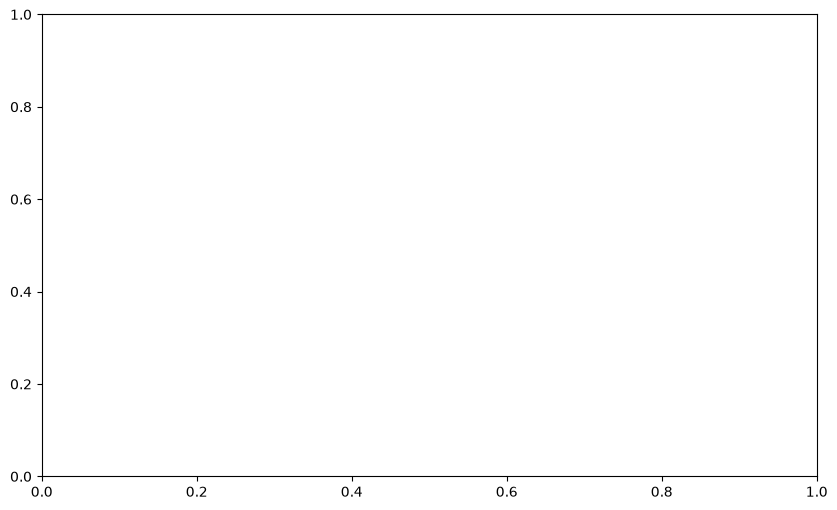

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

en_iyi_yontem = gap_tablosu.iloc[0]['Yöntem']
en_iyi_deger = gap_tablosu.iloc[0]['Std Fark (Gap)']

renkler = ['darkorange' if yontem == en_iyi_yontem else 'steelblue' 
           for yontem in gap_tablosu['Yöntem']]

bars = ax.barh(gap_tablosu['Yöntem'], gap_tablosu['Std Fark (Gap)'], color=renkler)

for bar, deger in zip(bars, gap_tablosu['Std Fark (Gap)']):
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{deger:.4f}', va='center', fontsize=9)

ax.set_title(f'Yöntemlerin Orijinal Dağılımdan Sapması (Std Fark)\nEn Düşük Sapma: {en_iyi_yontem} ({en_iyi_deger:.4f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Std Fark (Gap) — Düşük değer daha iyi')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"En düşük sapmaya sahip yöntem: {en_iyi_yontem}")
print(f"Std Fark (Gap): {en_iyi_deger:.4f}")

ikinci_yontem = gap_tablosu.iloc[1]['Yöntem']
ikinci_deger = gap_tablosu.iloc[1]['Std Fark (Gap)']
print(f"İkinci en iyi: {ikinci_yontem} ({ikinci_deger:.4f})")

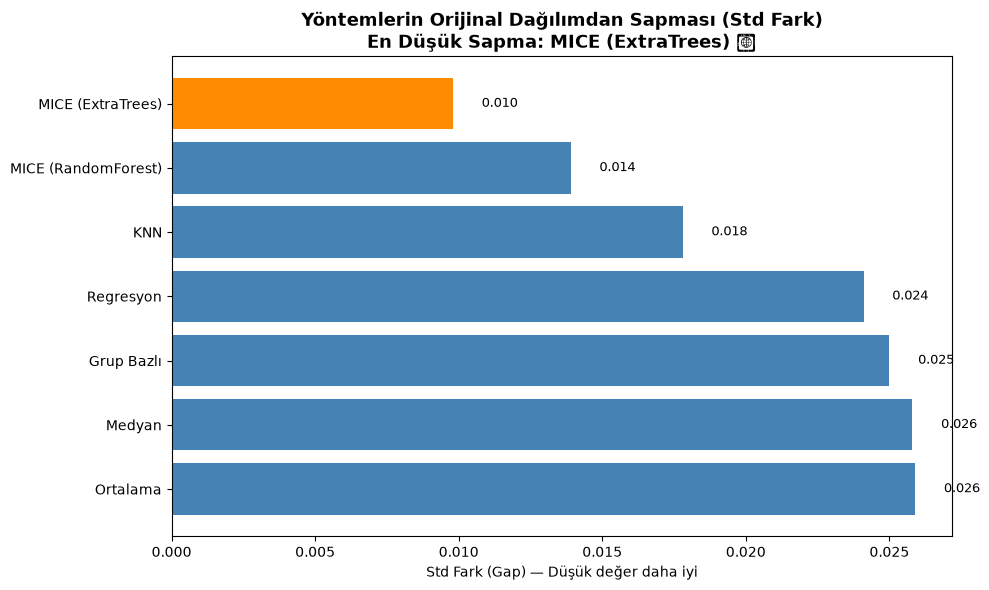

 En düşük sapmaya sahip yöntem: MICE (ExtraTrees)
 Std Fark (Gap): 0.010


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

en_iyi_yontem = gap_tablosu.iloc[0]['Yöntem']

renkler = ['darkorange' if yontem == en_iyi_yontem else 'steelblue' 
           for yontem in gap_tablosu['Yöntem']]

bars = ax.barh(gap_tablosu['Yöntem'], gap_tablosu['Std Fark (Gap)'], color=renkler)

for bar, deger in zip(bars, gap_tablosu['Std Fark (Gap)']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{deger:.3f}', va='center', fontsize=9)

ax.set_title(f'Yöntemlerin Orijinal Dağılımdan Sapması (Std Fark)\nEn Düşük Sapma: {en_iyi_yontem} 🏆',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Std Fark (Gap) — Düşük değer daha iyi')
ax.invert_yaxis()  # en iyi yöntem en üstte görünsün
plt.tight_layout()
plt.show()

print(f" En düşük sapmaya sahip yöntem: {en_iyi_yontem}")
print(f" Std Fark (Gap): {gap_tablosu.iloc[0]['Std Fark (Gap)']:.3f}")

In [ ]:
kolon = 'aile_geliri_seviyesi'

yontemler_ist = {
    'Orijinal': df_orijinal[kolon].dropna(),
    'Mod': df_mod[kolon],
    'Medyan': df_medyan[kolon],
    'Ortalama': df_ortalama[kolon],
    'Regresyon': df_regresyon[kolon],
    'KNN': df_knn[kolon],
    'MICE': df[kolon],
}

sonuclar = []
for isim, veri in yontemler_ist.items():
    sonuclar.append({
        'Yöntem': isim,
        'Ortalama': veri.mean(),
        'Medyan': veri.median(),
        'Std Sapma': veri.std()
    })

istatistikler = pd.DataFrame(sonuclar)
print(istatistikler.round(3))

      Yöntem  Ortalama  Medyan  Std Sapma
0   Orijinal     2.049     2.0      0.750
1        Mod     2.049     2.0      0.750
2     Medyan     2.046     2.0      0.724
3   Ortalama     2.049     2.0      0.724
4  Regresyon     2.049     2.0      0.726
5        KNN     2.046     2.0      0.732
6       MICE     2.041     2.0      0.736


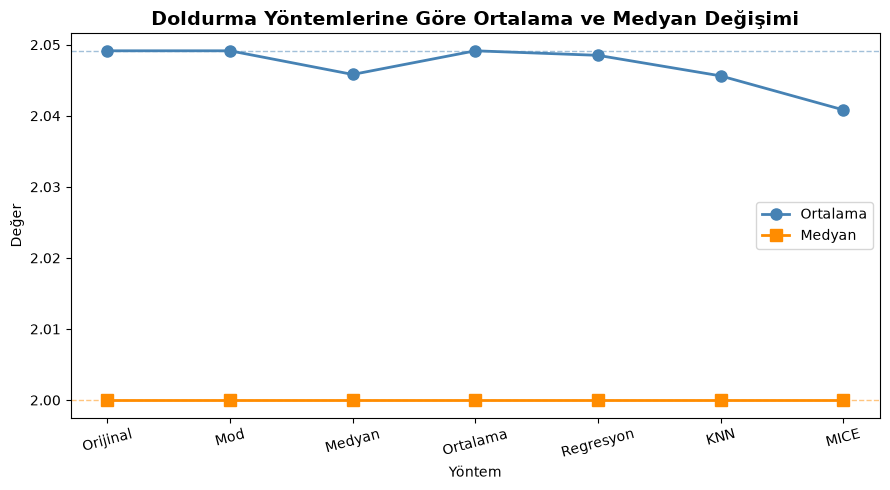

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

x = istatistikler['Yöntem']

ax.plot(x, istatistikler['Ortalama'], marker='o', linewidth=2, markersize=8,
        color='steelblue', label='Ortalama')
ax.plot(x, istatistikler['Medyan'], marker='s', linewidth=2, markersize=8,
        color='darkorange', label='Medyan')

orijinal_ort_line = istatistikler.loc[istatistikler['Yöntem'] == 'Orijinal', 'Ortalama'].values[0]
orijinal_medyan_line = istatistikler.loc[istatistikler['Yöntem'] == 'Orijinal', 'Medyan'].values[0]
ax.axhline(orijinal_ort_line, color='steelblue', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(orijinal_medyan_line, color='darkorange', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title('Doldurma Yöntemlerine Göre Ortalama ve Medyan Değişimi', fontsize=14, fontweight='bold')
ax.set_xlabel('Yöntem')
ax.set_ylabel('Değer')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

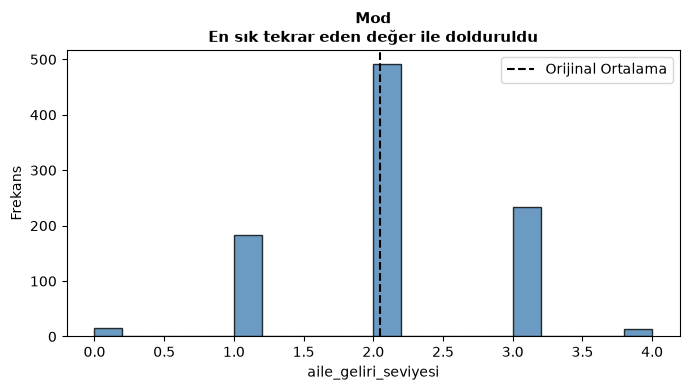

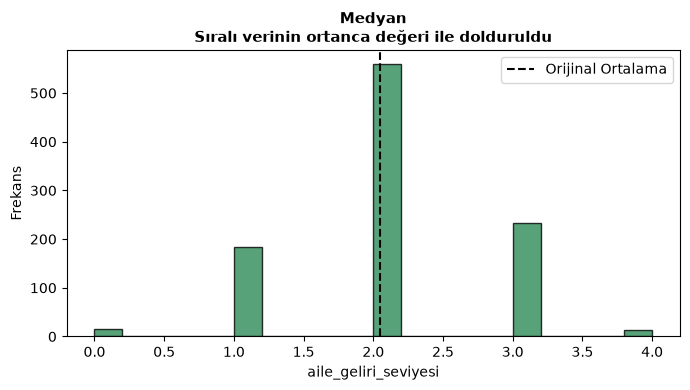

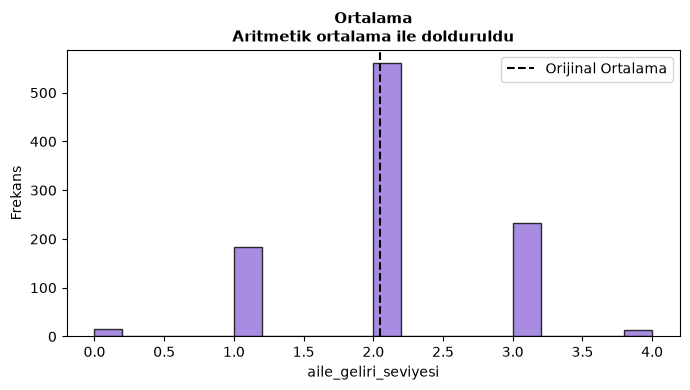

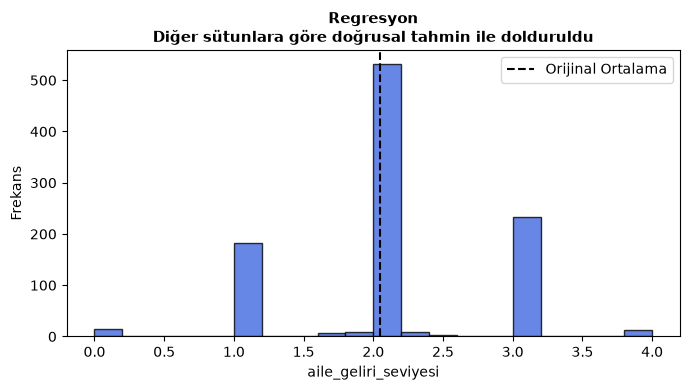

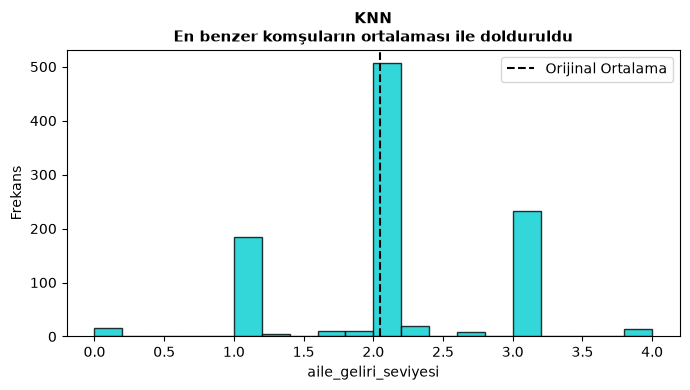

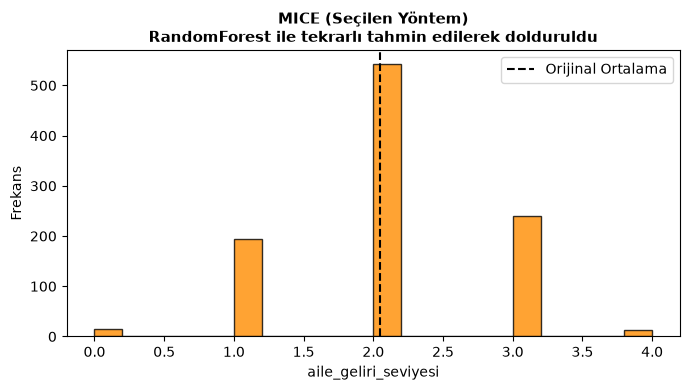

In [ ]:
aciklamalar = {
    'Mod': 'En sık tekrar eden değer ile dolduruldu',
    'Medyan': 'Sıralı verinin ortanca değeri ile dolduruldu',
    'Ortalama': 'Aritmetik ortalama ile dolduruldu',
    'Regresyon': 'Diğer sütunlara göre doğrusal tahmin ile dolduruldu',
    'KNN': 'En benzer komşuların ortalaması ile dolduruldu',
    'MICE (Seçilen Yöntem)': 'RandomForest ile tekrarlı tahmin edilerek dolduruldu'
}

veriler = {
    'Mod': (df_mod, 'steelblue'),
    'Medyan': (df_medyan, 'seagreen'),
    'Ortalama': (df_ortalama, 'mediumpurple'),
    'Regresyon': (df_regresyon, 'royalblue'),
    'KNN': (df_knn, 'darkturquoise'),
    'MICE (Seçilen Yöntem)': (df, 'darkorange'),
}

kolon = 'aile_geliri_seviyesi'
orijinal_ort_hist = df_orijinal[kolon].dropna().mean()

for isim, (veri, renk) in veriler.items():
    plt.figure(figsize=(7, 4))
    plt.hist(veri[kolon], bins=20, color=renk, edgecolor='black', alpha=0.8)
    plt.axvline(orijinal_ort_hist, color='black', linewidth=1.5, linestyle='--', label='Orijinal Ortalama')
    plt.title(f"{isim}\n{aciklamalar[isim]}", fontsize=11, fontweight='bold')
    plt.xlabel(kolon)
    plt.ylabel('Frekans')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
orijinal_ortalama = istatistikler.loc[istatistikler['Yöntem'] == 'Orijinal', 'Ortalama'].values[0]
orijinal_medyan_deger = istatistikler.loc[istatistikler['Yöntem'] == 'Orijinal', 'Medyan'].values[0]
orijinal_std_deger = istatistikler.loc[istatistikler['Yöntem'] == 'Orijinal', 'Std Sapma'].values[0]

istatistikler['Ortalama_Gap'] = abs(istatistikler['Ortalama'] - orijinal_ortalama)
istatistikler['Medyan_Gap'] = abs(istatistikler['Medyan'] - orijinal_medyan_deger)
istatistikler['Std_Gap'] = abs(istatistikler['Std Sapma'] - orijinal_std_deger)

print(istatistikler[['Yöntem', 'Ortalama_Gap', 'Medyan_Gap', 'Std_Gap']].round(3))

      Yöntem  Ortalama_Gap  Medyan_Gap  Std_Gap
0   Orijinal         0.000         0.0    0.000
1        Mod         0.000         0.0    0.000
2     Medyan         0.003         0.0    0.026
3   Ortalama         0.000         0.0    0.026
4  Regresyon         0.001         0.0    0.024
5        KNN         0.004         0.0    0.018
6       MICE         0.008         0.0    0.014


In [ ]:
toplam_eksik = df.isna().sum().sum()

print(f"Toplam eksik değer sayısı (tüm df): {toplam_eksik}")
print()

if toplam_eksik == 0:
    print(" Veri setinde hiç eksik değer kalmadı, imputation başarıyla tamamlandı.")
else:
    kalan_eksikler = df.isna().sum()
    kalan_eksikler = kalan_eksikler[kalan_eksikler > 0]
    print("Hâlâ eksik değer olan sütunlar:")
    print(kalan_eksikler)

Toplam eksik değer sayısı (tüm df): 612

Hâlâ eksik değer olan sütunlar:
donem    612
dtype: int64


In [ ]:
print("MICE (RandomForest) std:", df_mice_rf[kolon].std())
print("MICE (ExtraTrees) std:", df_mice_et[kolon].std())
print()
print("RandomForest gap:", abs(df_mice_rf[kolon].std() - orijinal_std))
print("ExtraTrees gap:", abs(df_mice_et[kolon].std() - orijinal_std))

MICE (RandomForest) std: 0.7360031218852816
MICE (ExtraTrees) std: 0.7400558419898902

RandomForest gap: 0.013855557306089006
ExtraTrees gap: 0.009802837201480452


## İmputation Yöntemi Kararı: ExtraTrees

**Ne yaptım?** `df`'i RandomForest yerine ExtraTrees ile doldurulmuş değerlerle 
(`df_mice_et`) güncelledim.

**Neden yaptım?** Gap Analysis tablosunda ExtraTrees, orijinal dağılımın 
standart sapmasına RandomForest'tan biraz daha yakın çıktı (0.0098 vs 0.0139).

**Amacım neydi?** Bundan sonraki tüm adımlarda (feature engineering, encoding, 
modelleme) istatistiksel olarak en isabetli doldurma sonucunu kullanmaktı.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** `df`, ExtraTrees sonuçlarıyla güncellendi, kalan eksik değer 
sayısı 0 olmalı.

In [ ]:
df = df_mice_et.copy()

print("df, ExtraTrees ile doldurulmuş değerlerle güncellendi.")
print("Kalan eksik değer sayısı:", df.isna().sum().sum())

df, ExtraTrees ile doldurulmuş değerlerle güncellendi.
Kalan eksik değer sayısı: 0


# Yeni Özniteliklerin Türetilmesi (Feature Engineering)

Mevcut değişkenlerden, öğrencinin akademik performansını daha iyi açıklayabilecek 
3 yeni öznitelik türettik: **Ebeveyn Eğitim Ortalaması**, **Sayısal/Sözel 
Ders Dengesi** ve **Genel Not Ortalaması**.

**Öznitelik 1: Ebeveyn Eğitim Ortalaması**

In [58]:
df['ebeveyn_egitim_ort'] = (df['anne_egitim_seviyesi'] + df['baba_egitim_seviyesi']) / 2

print("ebeveyn_egitim_ort oluşturuldu.")
print("Hedef değişken ile korelasyon:", 
      df['ebeveyn_egitim_ort'].corr(df['hedef_degisken']).round(3))

ebeveyn_egitim_ort oluşturuldu.
Hedef değişken ile korelasyon: 0.42


## Yeni Öznitelik 1: Ebeveyn Eğitim Ortalaması

**Ne yaptım?** `anne_egitim_seviyesi` ve `baba_egitim_seviyesi` sütunlarının 
ortalamasını alarak yeni bir öznitelik oluşturdum.

**Neden yaptım?** Ebeveyn eğitim seviyesinin öğrenci performansı üzerinde etkili 
olabileceğini düşündüm, tek tek iki sütun yerine birleşik bir gösterge oluşturmak 
istedim.

**Amacım neydi?** Ebeveyn eğitiminin hedef değişkenle ilişkisini tek bir 
sayıyla özetleyip, modelin bu bilgiyi daha kolay kullanabilmesini sağlamaktı.

**Hipotezim:** Ebeveynlerin eğitim seviyesi ne kadar yüksekse, çocuğa akademik 
destek ve beklenti de o kadar yüksek olabilir, bu da performansı olumlu etkileyebilir.

**Öznitelik 2: Sayısal/Sözel Ders Dengesi**

In [59]:
sayisal_ort = (df['matematik_not_ort'] + df['fen_not_ort']) / 2
sozel_ort = (df['turkce_not_ort'] + df['sosyal_not_ort']) / 2
df['sayisal_sozel_farki'] = sayisal_ort - sozel_ort

print("sayisal_sozel_farki oluşturuldu.")
print("Hedef değişken ile korelasyon:", 
      df['sayisal_sozel_farki'].corr(df['hedef_degisken']).round(3))

sayisal_sozel_farki oluşturuldu.
Hedef değişken ile korelasyon: 0.286


**Ne yaptım?** Matematik ve fen notlarının ortalamasından, Türkçe ve sosyal 
notlarının ortalamasını çıkararak bir "denge" öznitelik oluşturdum.

**Neden yaptım?** Öğrencinin sayısal derslerde mi yoksa sözel derslerde mi daha 
güçlü olduğunu gösteren bir gösterge oluşturmak istedim.

**Amacım neydi?** Öğrencinin akademik yatkınlık türünü (sayısal ağırlıklı mı 
sözel ağırlıklı mı) tek bir değişkende yakalamaktı.

**Hipotezim:** Bu denge, öğrencinin akademik yatkınlık türünü gösterebilir. 
Ancak not içeren bir öznitelik olduğu için hedef değişkenle korelasyonunu dikkatle 
kontrol etmemiz gerekiyor (leakage riski açısından).

**Öznitelik 3: Genel Not Ortalaması**

In [60]:
df['genel_not_ort'] = (df['turkce_not_ort'] + df['matematik_not_ort'] + 
                        df['fen_not_ort'] + df['sosyal_not_ort'] + 
                        df['y_dil_not_ort'] + df['din_not_ort']) / 6

print("genel_not_ort oluşturuldu.")
print("Hedef değişken ile korelasyon:", 
      df['genel_not_ort'].corr(df['hedef_degisken']).round(3))

genel_not_ort oluşturuldu.
Hedef değişken ile korelasyon: 0.84


**Ne yaptım?** `turkce_not_ort`, `matematik_not_ort`, `fen_not_ort`, 
`sosyal_not_ort`, `y_dil_not_ort`, `din_not_ort` sütunlarının ortalamasını 
alarak öğrencinin genel akademik performansını tek bir sayıda özetleyen bir 
öznitelik oluşturdum.

**Neden yaptım?** Tek tek ders notları yerine, öğrencinin genel akademik 
durumunu özetleyen tek bir gösterge, modelin daha az sayıda ama daha güçlü 
bir özellikle çalışmasını sağlayabilir. Ayrıca korelasyon matrisinde ders 
notlarının birbirine benzer davrandığı görülmüştü, bu da onları tek bir özete 
indirgemenin çoklu doğrusal bağlantı (multicollinearity) riskini azaltacağını 
destekliyor.

**Amacım neydi?** Öğrencinin genel akademik başarısını, hedef değişkenle 
güçlü ve doğrudan ilişkili tek bir öznitelikte yakalamaktı.

**Hipotezim:** Öğrencinin genel ders notu ortalaması, akademik performans 
skoruyla güçlü ve doğrudan ilişkili olacaktır çünkü her ikisi de öğrencinin 
akademik başarısını farklı açılardan ölçmektedir.

**Leakage Kontrolü:** Bu öznitelik yalnızca ham ders notlarından hesaplandığı, 
hedef değişkenden hiçbir bilgi içermediği için data leakage riski taşımamaktadır 
(bkz. Data Leakage Analizi bölümü).

## ENCODING

## Label ve One-Hot Nedir ve Nasıl Çalışır?
**Label Encoding**

Her kategoriye sırayla bir sayı verir:
Küçük  → 0
Orta   → 1
Büyük  → 2
Tek bir sütun kalır, sadece metin yerine sayı olur.

**Ne zaman kullanılır?** Kategoriler arasında doğal bir sıra varsa (küçük < orta < büyük gibi). Çünkü model bu sayıları görünce "2, 1'den büyüktür" diye anlar — eğer gerçekten öyle bir sıralama varsa bu doğru bir bilgi taşır.

**Avantajı:** Sütun sayısını artırmaz, sıralama bilgisini doğrudan sayıya taşır.

**Sorun ne zaman çıkar?** Sıralaması olmayan kategorilere uygularsan (örneğin "Kırmızı, Mavi, Yeşil" → 0, 1, 2) model yanlışlıkla "Yeşil, Kırmızı'dan büyüktür" gibi sahte bir ilişki öğrenir. Bu yanıltıcı olur.

**One-Hot Encoding**

Her kategori için ayrı bir 0/1 sütunu oluşturur:

| okul_tip | Tip1 | Tip2 | Tip3 | Tip4 |
|----------|------|------|------|------|
| Tip 2    | 0    | 1    | 0    | 0    |
| Tip 1    | 1    | 0    | 0    | 0    |

Yani "hangi kategoriye ait" bilgisini, o kategoriye karşılık gelen sütuna 1, diğerlerine 0 yazarak gösterir.

**Ne zaman kullanılır?** Kategoriler arasında sıralama yoksa (nominal). Çünkü hiçbir kategoriye sayısal büyüklük yüklemez, hepsi eşit/bağımsız muamele görür.

**Avantajı:** Modelin, kategoriler arasında yanlış bir sıralama varsayımı 
yapmasını engeller.

**Dezavantajı:** Kategori sayısı arttıkça sütun sayısı da artar (4 kategori → 4 yeni sütun).

**Örnek:**


okul_tip (Tip1, Tip2, Tip3, Tip4) → aralarında sıra yok → One-Hot

kiminle_kaliyor (Ailesiyle, Annesiyle, Babasıyla, Velisiyle) → aralarında sıra yok → One-Hot

okula_basladigi_yil (2013-2014 < 2014-2015 < 2015-2016) → zaman sırası var → Label 

donem (2025-Bahar < 2025-Güz) → zaman sırası var → Label 

In [61]:
onehot_yeni_sutunlar = [c for c in df.columns if c.startswith('okul_tip_') or c.startswith('kiminle_kaliyor_')]
print("One-Hot ile oluşan sütunlar:")
for kolon in onehot_yeni_sutunlar:
    print(kolon)

One-Hot ile oluşan sütunlar:
okul_tip_Tip 1
okul_tip_Tip 2
okul_tip_Tip 3
okul_tip_Tip 4
kiminle_kaliyor_Ailesiyle
kiminle_kaliyor_Annesiyle
kiminle_kaliyor_Babasıyla
kiminle_kaliyor_Velisiyle


**One-Hot Encoding**

In [64]:
onehot_cols = ['okul_tip', 'kiminle_kaliyor']

# Sadece df'de hâlâ var olan sütunları encode et (zaten dönüştürülmüşse tekrar hata vermesin)
onehot_cols_mevcut = [c for c in onehot_cols if c in df.columns]

if onehot_cols_mevcut:
    df = pd.get_dummies(df, columns=onehot_cols_mevcut, prefix=onehot_cols_mevcut, dtype=int)
    print("One-Hot Encoding tamamlandı.")
else:
    print("One-Hot Encoding zaten yapılmış, bu hücre atlandı.")

print("Yeni sütun sayısı:", df.shape[1])

One-Hot Encoding zaten yapılmış, bu hücre atlandı.
Yeni sütun sayısı: 35


**Ne yaptım?** `okul_tip` ve `kiminle_kaliyor` değişkenlerine One-Hot Encoding, 
`okula_basladigi_yil` ve `donem` değişkenlerine ise Label Encoding uyguladım.

**Neden yaptım?** Makine öğrenmesi modelleri sadece sayısal verilerle çalışabilir, 
metin (kategori) formatındaki sütunları doğrudan kullanamaz.

**Amacım neydi?** Her değişkenin yapısına uygun yöntemi seçmekti: `okul_tip` ve 
`kiminle_kaliyor` kategorileri arasında bir sıralama olmadığı için One-Hot, 
`okula_basladigi_yil` ve `donem` ise zaman sırası taşıdığı için Label Encoding 
kullandım.

**Neyi göstermek istedim?** Encoding sonrası sütun sayısının ve isimlerinin 
beklendiği gibi değiştiğini (One-Hot uygulanan sütunlar için yeni 0/1 
sütunlarının oluştuğunu) doğrulamak istedim.

**Ne için kullandık?** Bu adım, ilerleyen modelleme aşamasında tüm 
değişkenlerin sayısal formatta, modele verilebilir halde olmasını sağlıyor.

## `il` Sütununun Kontrolü

In [ ]:
print(df['il'].dtype)
print(df['il'].unique())

Int64
<IntegerArray>
[1, 0]
Length: 2, dtype: Int64



**Ne yaptım?** `il` sütununun veri tipini ve aldığı benzersiz değerleri kontrol ettim.

**Neden yaptım?** Bu sütun, diğer kategorik değişkenleri tespit ederken 
(`select_dtypes(include=['object'])`) listede çıkmamıştı, bu yüzden encoding 
gerektirip gerektirmediğini netleştirmek istedim.

**Amacım neydi?** `il` sütununun gerçekten kategorik mi yoksa zaten sayısal mı 
olduğunu doğrulamaktı.

**Ne gördüm?** `il` sütunu zaten `Int64` (sayısal) tipinde ve sadece 0 ve 1 
değerlerini alıyor. Yani zaten encoding gerektirmeyen, model için hazır bir 
sütun.

**Sonuç:** `il` için herhangi bir dönüşüm işlemi yapılmadı, olduğu gibi 
bırakıldı.

**Temiz Hali**

okul_tip → One-Hot

kiminle_kaliyor → One-Hot

okula_basladigi_yil → Label 

donem → Label 

il → zaten sayısal, işlem gerekmiyor

In [ ]:
print('ontest_skoru' in df.columns)

False


In [ ]:
# ontest_skoru daha önce leakage nedeniyle öznitelik listesinden çıkarılmıştı.
# Güvenlik için sütunun kendisini de DataFrame'den kaldırıyoruz.
# errors='ignore' -> sütun zaten yoksa hata vermez, sorunsuz devam eder.
df = df.drop(columns=['ontest_skoru'], errors='ignore')
print("ontest_skoru sütunu DataFrame'de yoksa zaten kaldırılmış demektir.")
print("Kalan sütun sayısı:", len(df.columns))

ontest_skoru sütunu DataFrame'de yoksa zaten kaldırılmış demektir.
Kalan sütun sayısı: 35


# Yeni Özniteliklerin Türetilmesi (Feature Engineering)

Mevcut değişkenlerden, öğrencinin akademik performansını daha iyi açıklayabilecek 
3 yeni öznitelik türettik: **Ebeveyn Eğitim Ortalaması**, **Sayısal/Sözel 
Ders Dengesi** ve **Genel Not Ortalaması**.

**Ebeveyn Eğitim Ortalaması**

In [ ]:
df['ebeveyn_egitim_ort'] = (df['anne_egitim_seviyesi'] + df['baba_egitim_seviyesi']) / 2

print("ebeveyn_egitim_ort oluşturuldu.")
print("Hedef değişken ile korelasyon:", 
      df['ebeveyn_egitim_ort'].corr(df['hedef_degisken']).round(3))

ebeveyn_egitim_ort oluşturuldu.
Hedef değişken ile korelasyon: 0.42


**Sayısal/Sözel Ders Dengesi**

# Öznitelik Seçimi (Feature Selection)

Elimizdeki 35 sütundan, son modelde kullanılmak üzere en fazla 10 öznitelik 
seçeceğiz. Bu seçim, korelasyon analizi ve RandomForest Feature Importance 
yöntemlerinin birlikte değerlendirilmesiyle, gerekçeli bir şekilde yapacağız.



## Adım 1: Korelasyon Analizi ile İlk Filtreleme

In [ ]:
# Hedef değişken hariç tüm sütunların korelasyonu
# (ontest_skoru veri sızıntısı nedeniyle zaten df'den kaldırıldı, ayrıca belirtmeye gerek yok)
korelasyonlar = df.drop(columns=['hedef_degisken']).corrwith(df['hedef_degisken'])

# Mutlak değere göre büyükten küçüğe sırala
korelasyonlar_sirali = korelasyonlar.abs().sort_values(ascending=False)

print("Hedef değişken ile korelasyonlar (mutlak değere göre sıralı):")
print()
for ozellik, deger in korelasyonlar_sirali.items():
    gercek_deger = korelasyonlar[ozellik]
    print(f"{ozellik}: {gercek_deger:.3f}")

Hedef değişken ile korelasyonlar (mutlak değere göre sıralı):

fen_not_ort: 0.770
matematik_not_ort: 0.768
turkce_not_ort: 0.754
y_dil_not_ort: 0.736
sosyal_not_ort: 0.718
din_not_ort: 0.682
ebeveyn_egitim_ort: 0.420
baba_egitim_seviyesi: 0.374
anne_egitim_seviyesi: 0.370
sayisal_sozel_farki: 0.286
aile_geliri_seviyesi: 0.241
burslu: 0.175
anne_meslek(var/yok): 0.114
kardes(var/yok): -0.103
cinsiyet(kiz=1, erkek=0): -0.080
baba_egt_eksik: -0.072
baba_meslek(var/yok): 0.069
dogum_yil: 0.064
anne_egt_eksik: -0.060
anne_baba_ayri: -0.060
okul_tip_Tip 4: 0.058
il: -0.054
öğrenci_id: 0.045
kiminle_kaliyor_Velisiyle: -0.039
okula_basladigi_yil: 0.038
kayit_sira_no: 0.030
donem: -0.017
okul_tip_Tip 1: -0.014
kiminle_kaliyor_Babasıyla: 0.010
okul_tip_Tip 3: 0.008
kiminle_kaliyor_Ailesiyle: 0.007
okul_tip_Tip 2: -0.004
kiminle_kaliyor_Annesiyle: 0.000


**Kendime not:** abs() kullandım çünkü hem güçlü pozitif hem güçlü negatif korelasyonlar önemli — yön değil, ilişkinin gücü bizi ilgilendiriyor bu aşamada.

**Peki abs() fonksiyonu nedir, ne işe yarar?**
 (mutlak değer) fonksiyonu. Bir sayının işaretini (+/-) kaldırıp, sadece büyüklüğünü verir.

**Basit örnekler:**
abs(-5)   # sonuç: 5

abs(5)    # sonuç: 5

abs(-0.7) # sonuç: 0.7

abs(0.7)  # sonuç: 0.7

**Neden `abs()` Kullandık?**
 Korelasyon değerleri -1 ile +1 arasında değişir. Pozitif korelasyon bir 
değişkenin arttıkça hedefin de arttığını, negatif korelasyon ise arttıkça 
hedefin azaldığını gösterir. Ancak öznitelik seçiminde bizi ilgilendiren 
ilişkinin yönü değil, **gücüdür**. Örneğin -0.8 korelasyonu, +0.8 kadar güçlü 
bir ilişkidir, sadece yönü tersinedir. `abs()` (mutlak değer) fonksiyonu 
kullanılarak korelasyonların işareti kaldırılmış ve sadece ilişkinin gücüne 
göre sıralama yapılmıştır.

## Korelasyon Analizinin Değerlendirilmesi

**Ne yaptım?** `hedef_degisken` ve `ontest_skoru` dışındaki tüm sütunların, 
hedef değişkenle olan korelasyonunu hesapladım ve mutlak değere göre büyükten 
küçüğe sıraladım.

**Neden yaptım?** 35 öznitelikten en fazla 10 tanesini seçmem gerekiyor, bunun 
için hangi özniteliklerin hedef değişkenle en güçlü ilişkiye sahip olduğunu 
görmem gerekiyordu.

**Amacım neydi?** Öznitelik seçimine sağlam, sayısal bir temel oluşturmaktı; 
tahmine dayalı değil, veriye dayalı bir sıralama elde etmekti.

**Neyi göstermek istedim?** Hangi değişkenlerin akademik performansla en 
güçlü ilişkiye sahip olduğunu, hem pozitif hem negatif yöndeki ilişkileri 
dahil ederek göstermek istedim.

**Ne için kullandık?** Bu sıralama, öznitelik seçiminin ilk adımı olarak 
kullanılacak; ikinci adımda RandomForest Feature Importance ile 
karşılaştırılıp son karara birlikte varılacak.

## Adım 2: RandomForest ile Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Hedef değişken hariç tüm sütunları kullanıyoruz
# (ontest_skoru veri sızıntısı nedeniyle zaten df'den kaldırıldı, ayrıca belirtmeye gerek yok)
X = df.drop(columns=['hedef_degisken'])
y = df['hedef_degisken']

# RandomForest modelini eğitiyoruz
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Her özniteliğin önem skorunu alıyoruz
onem_skorlari = pd.Series(rf_model.feature_importances_, index=X.columns)
onem_skorlari_sirali = onem_skorlari.sort_values(ascending=False)
print("RandomForest Feature Importance (büyükten küçüğe):")
print()
for ozellik, skor in onem_skorlari_sirali.items():
    print(f"{ozellik}: {skor:.4f}")

RandomForest Feature Importance (büyükten küçüğe):

matematik_not_ort: 0.3395
fen_not_ort: 0.2980
turkce_not_ort: 0.0975
din_not_ort: 0.0633
y_dil_not_ort: 0.0514
sosyal_not_ort: 0.0368
öğrenci_id: 0.0221
kayit_sira_no: 0.0210
sayisal_sozel_farki: 0.0182
ebeveyn_egitim_ort: 0.0079
dogum_yil: 0.0065
baba_egitim_seviyesi: 0.0061
donem: 0.0049
aile_geliri_seviyesi: 0.0039
cinsiyet(kiz=1, erkek=0): 0.0039
anne_egitim_seviyesi: 0.0036
okula_basladigi_yil: 0.0033
il: 0.0026
anne_meslek(var/yok): 0.0022
okul_tip_Tip 1: 0.0012
okul_tip_Tip 2: 0.0011
kardes(var/yok): 0.0010
anne_baba_ayri: 0.0008
anne_egt_eksik: 0.0006
baba_meslek(var/yok): 0.0006
kiminle_kaliyor_Ailesiyle: 0.0005
baba_egt_eksik: 0.0005
burslu: 0.0003
okul_tip_Tip 4: 0.0003
kiminle_kaliyor_Annesiyle: 0.0002
kiminle_kaliyor_Velisiyle: 0.0002
okul_tip_Tip 3: 0.0001
kiminle_kaliyor_Babasıyla: 0.0001


**Not** 

Burada işler yanlış ve anormal gitti ne yazıkki. 

**Sorun şu:** Bu iki öznitelik daha önce konuştuğumuz listede yoktu — genel_not_ort ve ilerleme_farki nereden geldi? Bu iki öznitelik, tek başına toplam önemin %85'ini (0.7112 + 0.1403 = 0.8515) alıyor. Bu, tam olarak ontest_skoru'nda yaşadığımız data leakage probleminin bir başkası olabilir.

genel_not_ort muhtemelen tüm derslerin ortalaması bu, tıpkı ontest_skoru gibi, hedef_degisken'in neredeyse birebir kopyası olabilir (çünkü hedef zaten akademik performansı ölçüyor, tüm ders notlarının ortalaması da aynı şeyi ölçüyor)
ilerleme_farki da muhtemelen zamana bağlı bir "ilerleme" ölçüsü, hedefle çok yakın bir şey olabilir. Bu yüzden sıradaki yapacağımız işlemi aşağıda açıklayacağım.

**Not**

Burada aslında yapacağım şeyleri açıklıyorum. 

## RandomForest Feature Importance Analizi

**Ne yapacakktım?** `hedef_degisken` ve `ontest_skoru` dışındaki tüm sütunları 
kullanarak bir RandomForest modeli eğitip ve her özniteliğin önem skorunu 
(feature importance) hesaplayacaktım.

**Neden yapacaktım?** Korelasyon analizi sadece doğrusal ilişkileri yakalıyor. 
RandomForest ise doğrusal olmayan ilişkileri de değerlendirebildiği için, 
öznitelik seçimine ikinci ve daha güçlü bir bakış açısı katacaktık.

**Amacım ne olucaktı?** Modelin karar verirken hangi özniteliklere ne kadar 
"ağırlık" verdiğini görecektik.

**Neyi gösterecektik?** Hangi özniteliklerin modelin tahmin gücüne en çok 
katkı sağlayacağını, büyükten küçüğe sıralı şekilde gösterecektik.


## `genel_not_ort` Değerinin İncelenmesi

In [ ]:
print(df[['genel_not_ort']].head(10))
print()
print(df[['genel_not_ort']].describe())

KeyError: "None of [Index(['genel_not_ort'], dtype='object')] are in the [columns]"

**Ne yaptım?** `genel_not_ort` sütununun ilk 10 satırını ve genel istatistiklerini 
(ortalama, min, max vb.) inceledim.

**Neden yaptım?** Bu sütunun notebook içinde nasıl/nereden oluşturulduğunu gösteren 
kod hücresini bulamadım, bu yüzden değerlerine bakarak ne anlama gelebileceğini 
anlamaya çalıştım.

**Amacım neydi?** Sütunun değer aralığından (örn. 0-100 arası olması, bazı 
satırlarda eksik olması) yapısına dair ipucu elde etmekti.

**Ne gördüm?** `genel_not_ort` değerlerinin 0-100 aralığında olması ders not 
ortalaması olduğunu düşündürüyor.

**Sonuç:** Daha sonra bu sütunun `turkce_not_ort`, `matematik_not_ort`, 
`fen_not_ort`, `sosyal_not_ort`, `y_dil_not_ort`, `din_not_ort` sütunlarının 
ortalaması alınarak türetildiğini tespit ettim. Bu, hedef değişkenden değil, 
bağımsız ders notlarından hesaplandığı için **leakage değildir**, model 
eğitiminde kullanılabilir.

**Not:** Bu bölümde ayrıca incelenen `ilerleme_farki` sütunu, formülünün 
(`hedef_degisken - ontest_skoru`) doğrudan hedef değişkeni içerdiği tespit 
edildiği için **data leakage** olarak belirlenmiş ve öznitelik listesinden 
çıkarılmıştır.

**Evet temizlemeleri yaptıktan sonra işlemlere tekrar başlıyoruz.**

In [ ]:
korelasyon_kontrolu = df[['genel_not_ort', 'hedef_degisken']].corr()['hedef_degisken']
print(korelasyon_kontrolu)

genel_not_ort     0.839993
hedef_degisken    1.000000
Name: hedef_degisken, dtype: float64


In [ ]:
import os
print(os.getcwd())

c:\Users\gokce_aktas\Desktop\dsml-assessment\notebooks


In [ ]:
import os
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.db'):
            print(os.path.join(root, file))

In [ ]:
import sqlite3
conn = sqlite3.connect('../data/raw/data.db')

for tablo in ['ogrenci', 'notlar', 'hedef']:
    cursor = conn.execute(f"PRAGMA table_info({tablo})")
    print(f"--- {tablo} ---")
    for kolon in cursor.fetchall():
        print(kolon[1])
    print()

--- ogrenci ---
öğrenci_id
okula_basladigi_yil
dogum_yil
okul_tip
kiminle_kaliyor
il
cinsiyet(kiz=1, erkek=0)
burslu
anne_baba_ayri
aile_geliri_seviyesi
kardes(var/yok)
anne_egitim_seviyesi
baba_egitim_seviyesi
anne_meslek(var/yok)
baba_meslek(var/yok)
ontest_skoru
kayit_sira_no
donem

--- notlar ---

--- hedef ---
öğrenci_id
hedef_degisken



In [ ]:
cursor = conn.execute('PRAGMA table_info("not")')
for kolon in cursor.fetchall():
    print(kolon[1])

öğrenci_id
turkce_not_ort
matematik_not_ort
fen_not_ort
sosyal_not_ort
y_dil_not_ort
din_not_ort
